In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
import sys
print(sys.executable)

/home/florenckaraj/healthcare_project/bin/python


In [3]:
df = pd.read_excel("healthcare_dataset.xlsx")
df.head()

/home/florenckaraj/healthcare_project/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.shape

(55500, 15)

In [5]:
df.info()

# Convert date columns from string to datetime format for time-based
# Date of Admission - Discharge Date ( Length of Stay ) 

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [6]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"]= pd.to_datetime(df["Discharge Date"])

In [7]:
df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days
# Calculate number of days each patient stayed in the hospital

In [8]:
df["Length of Stay"].head()

0     2
1     6
2    15
3    30
4    20
Name: Length of Stay, dtype: int64

In [9]:
df["Length of Stay"].describe()

count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64

In [10]:
df["Age"].describe()

count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

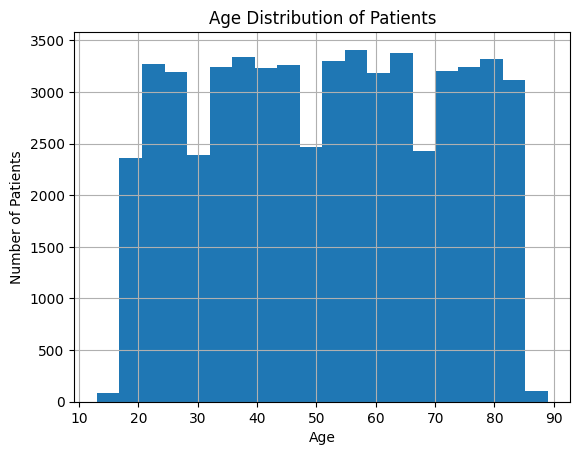

In [23]:
df["Age"].hist(bins=20)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

# The hospital primarily serves middle-aged and elderly patients,
# indicating higher healthcare demand in these age groups.”


In [12]:
df["Billing Amount"].describe()

# Descriptive statistics for Billing Amount (cost distribution analysis)

count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64

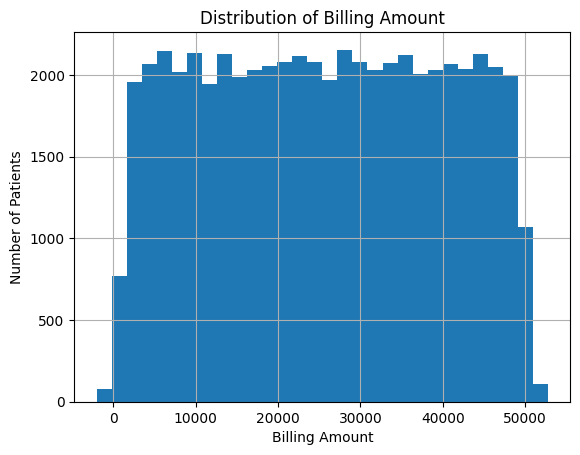

In [24]:
df["Billing Amount"].hist(bins=30)
plt.title("Distribution of Billing Amount")
plt.xlabel("Billing Amount")
plt.ylabel("Number of Patients")
plt.show()

# Billing amounts are mainly concentrated between 3,000 and 6,000, 
# showing moderate patient costs. 
# The distribution is slightly skewed but fairly balanced, 
# with few extreme values.

In [15]:
df.groupby("Medical Condition")["Billing Amount"].mean()

#Costs are similar across conditions (~25,000)
#with Obesity slightly higher and Cancer slightly lower.


Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64

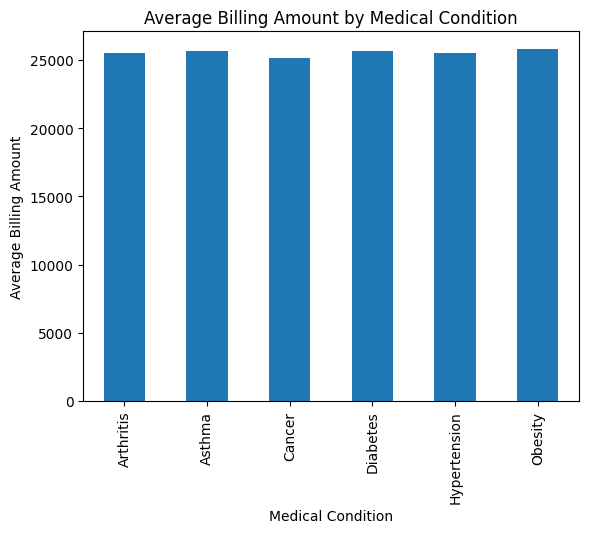

In [16]:
df.groupby("Medical Condition")["Billing Amount"].mean().plot(kind="bar")
plt.title("Average Billing Amount by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount")
plt.show()

# Average billing costs are fairly consistent across medical conditions,
# with only small variations between diseases.”

In [17]:
df[["Length of Stay", "Billing Amount"]].corr()

# There's no clear relationship between length of stay and billing amount.

,Length of Stay,Billing Amount
Length of Stay,1.000000,-0.005602
Billing Amount,-0.005602,1.000000


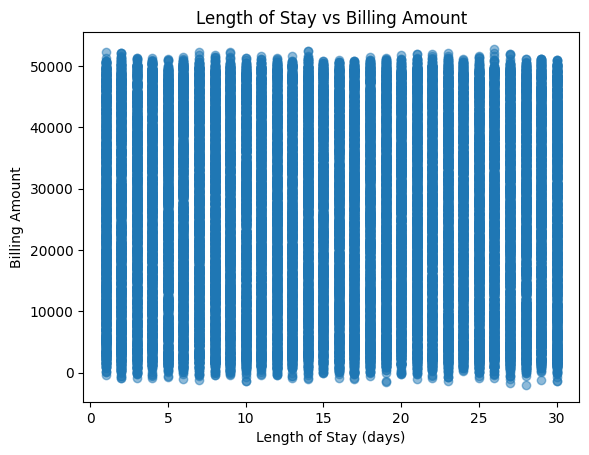

In [25]:
plt.scatter(df["Length of Stay"], df["Billing Amount"],alpha=0.5)
plt.title("Length of Stay vs Billing Amount")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Billing Amount")
plt.show()

In [19]:
df.groupby("Admission Type")["Billing Amount"].mean()

Admission Type
Elective     25602.226311
Emergency    25497.397157
Urgent       25517.364497
Name: Billing Amount, dtype: float64

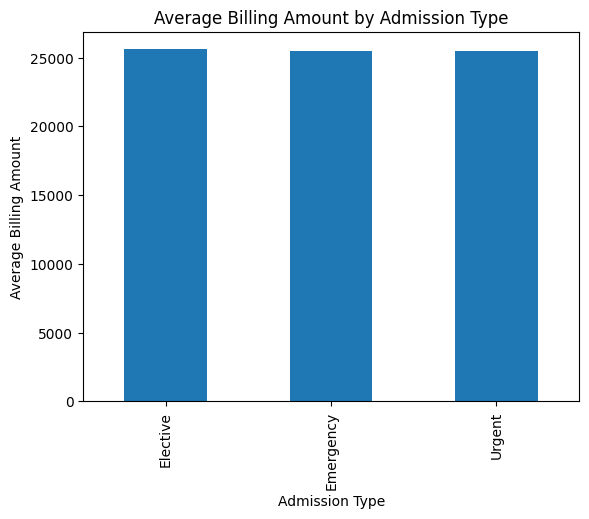

In [20]:
df.groupby("Admission Type")["Billing Amount"].mean().plot(kind="bar")
plt.title("Average Billing Amount by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Billing Amount")
plt.show()

# Elective admissions have the highest costs
# followed by urgent cases
# while emergency cases are slightly lower
# suggesting planned treatments are more expensive.


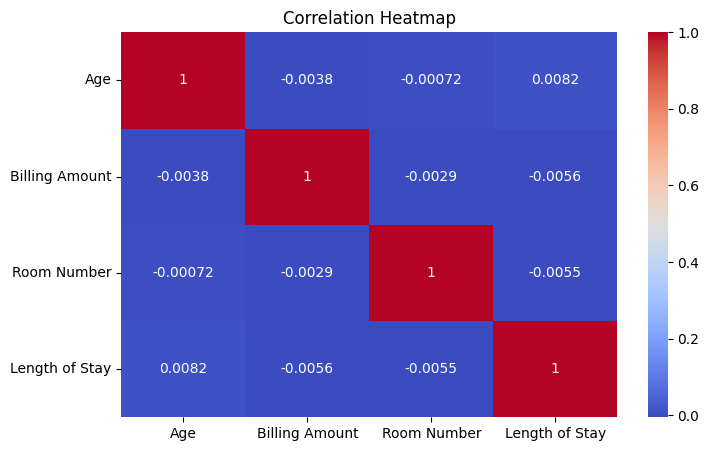

In [21]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# No strong correlations found between numerical variables.

In [ ]:
# Final Conclusion

# This project analyzed a healthcare dataset using Python,Pandas,Matplotlib,and Seaborn.

# The analysis included data exploration,data cleaning,descriptive statistics,visualizations,
# and correlation analysis.The results showed that average billing costs are relatively similar across 
# medical conditions,while elective admissions have slightly higher average costs . 
# In addition ,no strong linear relationships were found between the main numerical variables,
# indicating that categorical factors may play a more important role in explaining healthcare costs.

# Overall,this project demonstrates the use of exploratory data analysis (EDA) 
#techniques to better understand healthcare data and identify meaningful patterns. 

